# Analisis de rendimiento CONMEBOL y UEFA

Durante el desarrolo del mundial 2026, se ha dado una conversacion respecto al rendimiento de CONMEBOL en mundiales en contraste con el de la UEFA, especificamente en etapas finales eliminatorias (principalmente cuartos en adelante).
Muchos sudamericanos hemos alentado por las selecciones CONMEBOL en la gran mayoria de sus enfrentamientos, y aun mas si se trataba con algun equipo de la UEFA (ej: Colombia-Suiza, Alemania-Paraguay).

Algo por lo que se lo ha criticado mucho a CONMEBOL fue por su escasa representacion en dichas etapas eliminatorias mas avanzadas en el torneo, alegando que la diferencia que saca la UEFA, que se ve considerablemente mas presente.
Motivado por esto, quiero desarrollar en este notebook un pequeño analisis al respecto.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import empiricaldist
import sqlite3
import scipy.stats
conn = sqlite3.connect("../data/Datos_Limpios.db")

## Obteniendo los datos
Conectemonos a world_cup_matches para obtener informacion de mundiales.

In [2]:
query = """
SELECT * 
FROM world_cup_matches
"""
wcm = pd.read_sql_query(query, conn)
wcm

,match_id,date,home_team,home_team_id,away_team,away_team_id,round,home_score,away_score,neutral,...,away_penalty_score,home_xg,away_xg,home_possession,away_possession,home_sot,away_sot,home_shots,away_shots,result
0,1408,1930-07-13,United States,175,Belgium,17,Group stage,3,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,home team win
1,1409,1930-07-13,France,61,Mexico,110,Group stage,4,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,home team win
2,1410,1930-07-14,Yugoslavia,144,Brazil,25,Group stage,2,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,home team win
3,1411,1930-07-14,Romania,139,Peru,134,Group stage,3,1,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,home team win
4,1412,1930-07-15,Argentina,7,France,61,Group stage,1,0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,home team win
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1063,48061,2026-07-11,Norway,127,England,53,Quarter-finals,1,2,1,...,NaN,0.77,0.96,48.0,52.0,4.0,8.0,13.0,14.0,away team win
1064,48062,2026-07-14,France,61,Spain,155,Semi-finals,0,2,1,...,NaN,0.30,1.63,49.0,51.0,3.0,2.0,10.0,10.0,away team win
1065,48063,2026-07-15,England,53,Argentina,7,Semi-finals,1,2,1,...,NaN,0.54,1.80,36.0,64.0,2.0,5.0,5.0,15.0,away team win
1066,48064,2026-07-18,France,61,England,53,Third-place match,4,6,1,...,NaN,2.88,2.88,46.0,54.0,9.0,11.0,19.0,19.0,away team win


Esta base de datos utiliza para identificar inequivocamente a cada equipo un team_id.  
 Esto por que identificar cada equipo por medio de su nombre en un string puede traer complicaciones:

-Un string typeado distinto.

-Un pais cambiando su nombre, por lo cual en los torneos dos strings distintos representan al mismo pais.

-Casos como el de Alemania, que en 1949 se dividio en Alemania Federal y en Republica Democratica Alemana, para volver a unirse en Alemania en 1990.

Por lo tanto antes de seguir con el analisis, para poder identificar correctamente que equipo pertenece a cada confederacion, extraeremos de la base de datos teams_master.   
La cual contiene para cada equipo su team_id, nombre, y confederacion a la que pertenece.


In [3]:
query = """
SELECT * 
FROM teams_master
"""
tm = pd.read_sql_query(query, conn)
tm

,team_id,canonical_name,fifa_code,confederation
0,1,Afghanistan,AFG,AFC
1,2,Albania,ALB,UEFA
2,3,Algeria,ALG,CAF
3,4,Andorra,AND,UEFA
4,5,Angola,ANG,CAF
...,...,...,...,...
231,232,Palau,PLW,AFC
232,233,São Tomé and Príncipe,NaN,CAF
233,234,Saint Vincent and the Grenadines,NaN,CONCACAF
234,235,Saint Kitts and Nevis,NaN,CONCACAF


Con esto ya podemos ubicar para cada equipo su confederacion.  
Creemos esta columna en world_cup_matches wcm utilizando teams_master tm.
El siguiente query crea por medio de un join la columna home confederation, vinculando team_id de tm con home_team_id de wcm. Luego inserta esa columna en wcm.

In [ ]:
query = "SELECT confederation FROM world_cup_matches wcm LEFT JOIN teams_master tm ON wcm.home_team_id = tm.team_id";
home_confederation = pd.read_sql_query(query, conn)
wcm["home_confederation"] = home_confederation


Ahora hagamos lo mismo con away team.

In [5]:
query = "SELECT confederation FROM world_cup_matches wcm LEFT JOIN teams_master tm ON wcm.away_team_id = tm.team_id";
away_confederation = pd.read_sql_query(query, conn)
wcm["away_confederation"] = away_confederation

Ahora con esto, podemos contar dos cosas:  
-La cantidad de equipos que representan a cada confederacion por edicion mundialista.  
-La cantidad de equipos en cada edicion mundialista.

Tomemos por ejemplo, el ultimo mundial:  
La columna date de wcm esta guardada como un string del tipo "año-mes-dia", pasemosla a formato Date de pandas para trabajar con esta correctamente.


In [6]:
wcm["date"] = pd.to_datetime(wcm["date"])
wcm_2026 = wcm[wcm["date"].dt.year == 2026]

equipos = pd.concat([
    wcm_2026[["home_team_id", "home_confederation"]].rename(
        columns={"home_team_id": "team_id",
                 "home_confederation": "confederation"}
    ),
    wcm_2026[["away_team_id", "away_confederation"]].rename(
        columns={"away_team_id": "team_id",
                 "away_confederation": "confederation"}
    )
]).drop_duplicates("team_id")

El codigo anterior consigue la cantidad de equipos del mundial wcm_2026, lo consigue contando la cantidad de team_id distintos que aparecen, contando en home_team_id y en away_team_id.

Si contaramos por solo una de estas columnas, tomemos como ejemplo home_team_id, en el caso de que un equipo en todos sus partidos haya sido registrado como visitante (lo cual podria pasar porque un equipo puede tener 3 partidos en todo el mundial), no apareceria su id en home_team_id por lo cual no quedaria registrado.  
Por eso buscamos todos los valores unicos que salen de juntar home_team_id y away_team_id

In [7]:

cant_equipos = len(equipos)
equipos_por_confederacion = (equipos.groupby("confederation")["team_id"].nunique())

representacion_conmebol = equipos_por_confederacion["CONMEBOL"] / cant_equipos

cant_equipos, equipos_por_confederacion["CONMEBOL"], representacion_conmebol

(48, np.int64(6), np.float64(0.125))

## Estableciendo la hipotesis nula

Hay 48 equipos en el mundial 2026, de los cuales 6 son de CONMEBOL y 16 de UEFA.
Tomemos como hipotesis nula (Ho) que todas las selecciones rindieran igual (es decir que la probabilidad de que cada equipo le gane a cualquier equipo sea 50%), y simulemos la distribucion de semifinalistas provenientes de CONMEBOL.  
Por lo tanto la representacion esperada de CONMEBOL, en cada etapa, deberia ser del 12.5%, es decir, 1 de cada 8 equipos deberia de ser CONMEBOL por cada fase.

Lo mas probable bajo esta hipotesis es que hayan 2 semifinalistas UEFA por mundial y como mucho 1 CONMEBOL. Por lo cual es posible uno de los motivos por los cuales CONMEBOL no tiene tanta presencia en fases posteriores eliminatorias, aparte del nivel sea por tamaño de muestra:

Ahora, hagamos con esta informacion un testeo:
 ¿Cual seria las probabilidad de que si en el torneo la representacion de una confederacion es (por ejemplo) 12.5%, la cantidad de semifinalistas de esta confederacion sea 2?  
 Es decir, una representacion observada del 50%.

La distribucion hipergeometrica nos deberia permitir modelar este evento:

 "La distribución hipergeométrica calcula la probabilidad de obtener una cantidad determinada de éxitos x al seleccionar una muestra de tamaño n, sin reemplazo, de una población de tamaño N que contiene K éxitos."

Podemos simular la cantidad de semifinalistas de CONMEBOL mediante una distribucion hipergeometrica bajo la hipotesis nula. La cual permite calcular la probabilidad de obtener cada cantidad posible de semifinalistas.  
Con esto, si observamos 2 semifinalistas de CONMEBOL, podemos calcular el valor p como la probabilidad de obtener 2 semifinalistas o mas bajo esta distribucion.

Empecemos extrayendo el modulo hypergeom de scipy.stats, luego hacemos que nuestros valores x sean de 0 a 4, siendo estos la cantidad posible de semifinalistas que puede haber de CONMEBOL, luego hacemos una pmf de la probabilidades de estos valores x bajo la distribucion hipergeometrica.  
(La funcion pmf del objeto hypergeom calcula la pmf empirica de la distribucion de los resultados de una distribucion hipergeometrica con los datos brindados).

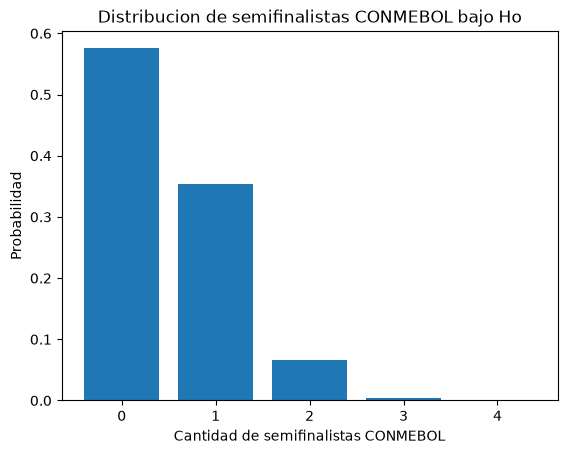

In [8]:
from scipy.stats import hypergeom

x = np.arange(5)

probabilidades = hypergeom.pmf(
    x, #cantidad de exitos (semifinalistas) en la muestra que sacamos
    M=cant_equipos, #tamaño poblacion
    n=equipos_por_confederacion["CONMEBOL"],  
    N=4 # tamaño de muestra que sacamos, 4 semifinalistas
)#Calculamos su pmf
plt.bar(x, probabilidades)
plt.xlabel("Cantidad de semifinalistas CONMEBOL")
plt.ylabel("Probabilidad")
plt.title("Distribucion de semifinalistas CONMEBOL bajo Ho")
plt.show()

Vemos que lo mas probable bajo estos datos es que no no hayan semifinalistas sudamaricanos, o que haya solo 1.
Que hayan 2 es un evento raro, y que hayan 3 ya es un evento muy improbable. 




## Simulando los datos
La funcion rvs del objeto hypergeom genera una muestra aleatoria de tamaño size de una distribucion hipergeometrica con los parametros dados.

In [ ]:
simulated = hypergeom.rvs(
    M=cant_equipos,
    n=equipos_por_confederacion["CONMEBOL"],
    N=4,
    size=100_000,
    random_state=42
)

Calculemos el valor p de que hayan 2 semifinalistas sudamericanos bajo un modelo que siga la hipotesis nula:

In [18]:
def compute_p_value(simulated, observed):
 """Fraction of simulated values as big or bigger than the observed value."""
 return (np.asarray(simulated) >= observed).mean()

compute_p_value(simulated, observed=2)

np.float64(0.40574)

El valor p de que 2 semifinalistas sean CONMEBOL en una edicion mundialista como la de 2026, con 48 equipos y 6 CONMEBOL, es de 0.07. 
Podemos ver que obtener 2 o mas semifinalistas CONMEBOL es un resultado relativamente bajo con este modelo bajo la hipotesis nula.  
El valor p de este resultado bajo el modelo indica que este evento ocurre aproximadamente en un 7% de los torneos. Lo cual sugiere que 2 o mas semifinalistas CONMEBOL es un resultado poco frecuente, pero no suficiente para contrarrestar la hipotesis nula porque el desempeño de CONMEBOL fue mayor de lo esperado bajo esta.

Podemos usar este modelo para tambien calcular la probabilidad de que en 2026 hayan habido 3 semifinalistas europeos:

In [13]:

simulated = hypergeom.rvs(
    M=cant_equipos,
    n=equipos_por_confederacion["UEFA"],
    N=4,
    size=100_000,
    random_state=42
)

compute_p_value(simulated, observed=2)

np.float64(0.40574)

Podemos generalizar este procedimiento en una funcion la cual dada una edicion de mundial, una confederacion y una cantidad de semifinalistas, devuelva el valor p de que esa confederacion se vea representada por esa cantidad de semifinalistas en el torneo:

In [12]:
def valor_p_cantidad_de_semifinalistas(año, confederacion, semifinalistas):
    wcm_año = wcm[wcm["date"].dt.year == año]

    equipos = pd.concat([
    wcm_año[["home_team_id", "home_confederation"]].rename(
        columns={"home_team_id": "team_id",
                 "home_confederation": "confederation"}),
    wcm_año[["away_team_id", "away_confederation"]].rename(
        columns={"away_team_id": "team_id",
                 "away_confederation": "confederation"})
     ]).drop_duplicates("team_id")

    cantidad_equipos= len(equipos)
    equipos_confederacion = (equipos.groupby("confederation")["team_id"].nunique())

    simulado = hypergeom.rvs(
        M=cantidad_equipos,
        n=equipos_confederacion[confederacion],
        N=4,
        size=100_000,
        random_state=42
    )
    return compute_p_value(simulado, observed=semifinalistas)

Comprobemos la funcion con los resultados que obtuvimos


In [15]:
valor_p_cantidad_de_semifinalistas(2026, "CONMEBOL", 2), valor_p_cantidad_de_semifinalistas(2026, "UEFA", 2)

(np.float64(0.07026), np.float64(0.40574))

Tambien podemos mostrar visualmente con la pmf de ambas simulaciones como contrastan las probabilidades de que los semifinalistas de estas confederaciones tengan presencia en semifinales:

In [14]:
pmf_CONMEBOL = hypergeom.pmf(
    x,
    M=48,
    n=6,
    N=4,
)

pmf_UEFA = hypergeom.pmf(
    x,
    M=48,
    n=16,
    N=4,
)

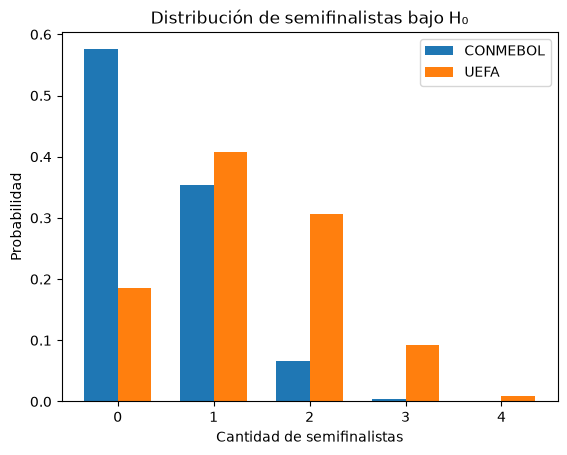

In [17]:
import matplotlib.pyplot as plt
import numpy as np

width = 0.35

plt.bar(x - width/2, pmf_CONMEBOL, width, label="CONMEBOL")
plt.bar(x + width/2, pmf_UEFA, width, label="UEFA")

plt.xlabel("Cantidad de semifinalistas")
plt.ylabel("Probabilidad")
plt.title("Distribución de semifinalistas bajo H₀")

plt.xticks(x)
plt.legend()

plt.show()

## Conclusion
La diferencia entre las distribuciones de los resultados de ambas confederaciones aparece incluso sin introducir diferencia de calidad entre las confederaciones, sino solo con el tamaño de muestra de ambas. Esto lo convierte en un factor que afecta la presencia de estos en cada fase.  
Por lo cual comparar directamente la cantidad de semifinalistas de ambas confederaciones sin tomar en cuenta su representacion en el torneo puede resultar engañoso.  
Exigirle a CONMEBOL que deberia tener dos semifinalistas es distinto a exigirle lo mismo a UEFA. Aun con igualdad de rendimiento ambos resultados tienen probabilidades muy diferentes unicamente por el tamaño de sus representantes.